In [2]:
# The following lines enable automatic reloading of modules in an IPython/Jupyter environment.
# They work exactly like the commented lines below, but avoid errors when not running in such an environment.
# %load_ext autoreload
# %autoreload 2

try:
    # Only defined inside IPython/Jupyter
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except (NameError, AttributeError):
    # Not running in IPython → just ignore
    pass


In [3]:
# Initializing answer variable
answer = {}


In [4]:
# Some libs that we will use
import torch
import random
import numpy as np
import json_tricks
import lovely_tensors as lt
from pprint import pprint

# Making tensor printouts better
lt.monkey_patch()

# Adding sources to the pythonpath
import sys
root_path = '../../../..'
sys.path.append(root_path)

import dotenv
dotenv.load_dotenv(dotenv.find_dotenv(root_path + '/.env'))

# Importing sources of our project
import src
import src.utils as utils


# Description

In this notebook, we will do experiments on how does the network's architecture affect the training process.
We will work with the same setup that we worked in Shallow Feedforward Networks, and we will try the following experiments:

- we will try to make the network deep without any modifications
- when we will encounter a problem in training a network -- we will try to figure out, what happens

All these experiments will be carried out on a toy dataset -- MNIST

Note thought that all of the effects that we observe in this notebook, will scale to more complex tasks

In [5]:
src.utils.seed.seed_all(0)

# Seed checks
seed_check = {
    'python.random': [random.random() for _ in range(4)],
    'python.randint': [random.randint(0, 9) for _ in range(4)],
    'numpy.random.rand': np.random.rand(2, 3),
    'numpy.random.randn': np.random.randn(2, 3),
    'numpy.random.randint': np.random.randint(0, 10, size=(2, 3)),
    'torch.rand': torch.rand(2, 3),
    'torch.randn': torch.randn(2, 3),
    'torch.randint': torch.randint(0, 10, (2, 3)),
    'torch.backends.cudnn.deterministic': torch.backends.cudnn.deterministic,
    'torch.cuda.is_available': torch.cuda.is_available(),
}

if seed_check['torch.cuda.is_available']:
    seed_check['torch.cuda.initial_seed'] = torch.cuda.initial_seed()
    seed_check['torch.cuda.rand'] = torch.rand(2, 3, device='cuda').cpu()
    seed_check['torch.cuda.randn'] = torch.randn(2, 3, device='cuda').cpu()
    seed_check['torch.cuda.randint'] = torch.randint(0, 10, (2, 3), device='cuda').cpu()

answer['seed_check'] = src.utils.detach_copy(seed_check)

print("!!! THE VALUES BELOW SHOULD BE STABLE FOR DIFFERENT RUNS !!!")
print()
pprint(seed_check)

!!! THE VALUES BELOW SHOULD BE STABLE FOR DIFFERENT RUNS !!!

{'numpy.random.rand': array([[0.5488135 , 0.71518937, 0.60276338],
       [0.54488318, 0.4236548 , 0.64589411]]),
 'numpy.random.randint': array([[8, 1, 5],
       [9, 8, 9]]),
 'numpy.random.randn': array([[ 0.95008842, -0.15135721, -0.10321885],
       [ 0.4105985 ,  0.14404357,  1.45427351]]),
 'python.randint': [8, 7, 6, 4],
 'python.random': [0.8444218515250481,
                   0.7579544029403025,
                   0.420571580830845,
                   0.25891675029296335],
 'torch.backends.cudnn.deterministic': True,
 'torch.cuda.is_available': False,
 'torch.rand': tensor[2, 3] n=6 x∈[0.088, 0.768] μ=0.404 σ=0.275 [[0.496, 0.768, 0.088], [0.132, 0.307, 0.634]],
 'torch.randint': tensor[2, 3] i64 n=6 x∈[1, 9] μ=4.500 σ=2.739 [[4, 3, 6], [9, 1, 4]],
 'torch.randn': tensor[2, 3] n=6 x∈[-0.783, 1.264] μ=0.068 σ=0.914 [[1.264, -0.687, 0.160], [-0.606, -0.783, 1.062]]}


In [6]:
MNIST_train = src.datasets.mnist_simple.MNISTSimpleDataset(train=True)
MNIST_valid = src.datasets.mnist_simple.MNISTSimpleDataset(train=False)

In [7]:
train_sample = MNIST_train[0]
valid_sample = MNIST_valid[0]

X_train = train_sample['image']
X_valid = valid_sample['image']
y_train = train_sample['label']
y_valid = valid_sample['label']


In [8]:
## This checks are for dataset verification
answer['X_train.dtype'] = str(X_train.dtype)
answer['y_train.dtype'] = str(y_train.dtype)
answer['X_valid.dtype'] = str(X_valid.dtype)
answer['y_valid.dtype'] = str(y_valid.dtype)
answer['X_train.shape'] = X_train.shape
answer['X_valid.shape'] = X_valid.shape
answer['y_train.shape'] = y_train.shape
answer['y_valid.shape'] = y_valid.shape
answer['X_train.mean'] = float(X_train.mean())
answer['y_train.mean'] = float(y_train.float().mean())
answer['X_valid.mean'] = float(X_valid.mean())
answer['y_valid.mean'] = float(y_valid.float().mean())

print('\nX_train dtype:', X_train.dtype, '\nX_valid dtype:', X_valid.dtype, '\ny_train dtype', y_train.dtype, '\ny_valid dtype:', y_valid.dtype)
print('\nX_train shape:', X_train.shape, '\nX_valid shape', X_valid.shape, '\ny_train shape:', y_train.shape, '\ny_valid shape:', y_valid.shape)

print()
print('X train:', X_train)
print('X_valid:', X_valid)
print('y_train:', y_train)
print('y_valid:', y_valid)



X_train dtype: torch.float32 
X_valid dtype: torch.float32 
y_train dtype torch.int64 
y_valid dtype: torch.int64

X_train shape: torch.Size([28, 28]) 
X_valid shape torch.Size([28, 28]) 
y_train shape: torch.Size([]) 
y_valid shape: torch.Size([])

X train: tensor[28, 28] n=784 (3.1Kb) x∈[-1.000, 1.000] μ=-0.725 σ=0.625
X_valid: tensor[28, 28] n=784 (3.1Kb) x∈[-1.000, 1.000] μ=-0.815 σ=0.518
y_train: tensor i64 5
y_valid: tensor i64 7


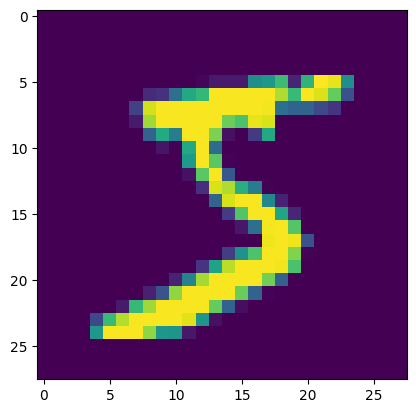

tensor i64 5


In [9]:
import matplotlib.pyplot as plt
plt.imshow(X_train)
plt.show()
print(y_train)


# Task 1: Create a simple deep network

It is time to create our neural network. Edit [src/models/feedforward/deep_batchnorm_net.py](../../../../src/models/feedforward/deep_batchnorm_net.py); it should open automatically with this chapter.

In this task you have to create the class `DeepFullyConnectedNet`.

The design of this network is the following:
- it takes the input vector of dimensionality `dim_input`
- projects it to embedding space using an encoder (a simple linear transform `torch.nn.Linear`) of dimentinoality `dim_embed`
- applies a sequence of `blocks` to the embedding
- after the last block is complete, applies a decoder (a simple linear transform `torch.nn.Linear`) to the dimentionality `dim_output` (that in the end is treated as the logits)

By default, the blocks should be `Linear -> activation -> Linear` (following the network-in-network logic)

NOTE: In PyTorch, trainable models usually inherit from `torch.nn.Module`. This gives the model access to parameters, submodules, `model.train()`, `model.eval()`, optimizers, hooks, device movement, and other PyTorch machinery that will become increasingly important in the future.

## Batch Protocol

We will use the batch updating protocol described above: the model reads images from `batch['data']['image']`, writes logits to `batch['signals']['output']`, and writes predicted classes to `batch['postprocessed']['class']`.

## Parts To Implement

Implement three parts:
- `__init__`, which creates the modules of the neural network. Remember to initialize the parent `torch.nn.Module` with `super().__init__()`.
- `__forward_kernel`, which receives an image tensor, flattens it from `[batch, 28, 28]` to `[batch, 784]`, passes it through the blocks, and returns raw logits. This method is also used for the model visualization.
- `forward`, which receives the nested batch dictionary, reads `batch['data']['image']`, calls `__forward_kernel`, stores logits in `batch['signals']['output']`, calls `argmax` to get predicted classes, and stores them in `batch['postprocessed']['class']`.


Let us check that your network runs and produces logits with the expected shape.


In [10]:
# simple_network = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
# simple_network = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(

from src.models.feedforward.deep_batchnorm_net import DeepFullyConnectedNet

simple_network = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
    dim_input=28 * 28, 
    dim_embed=64,
    dim_output=10,
    n_blocks=3)

# ^^^ This class should be implemented in this task

# Here we intialize the network so that the initial state is predictable
utils.deterministic_init(simple_network)

# Here we are creating a sample batch with the same keys as MNISTSimpleDataset
check_batch = {'data': {'image': torch.randn(10, 28, 28), 'label': torch.randint(low=0, high=10, size=(10,))}}

# And checking how it traverses through the network
check_output = simple_network(check_batch)

print('output:', check_batch['signals']['output'].shape)
print('classes:', check_batch['postprocessed']['class'].shape)

# And saving the result
pprint(check_batch)
answer['check_batch'] = check_batch


AttributeError: module 'src.models.feedforward' has no attribute 'deep_batchnorm_net'

# Task 2

Edit [src/models/feedforward/deep_batchnorm_net.py](../../../../src/models/feedforward/deep_batchnorm_net.py).

Create an `Bottleneck` block. At first, we will work with blocks that contain:

- PreNormalization (the constuctor function should be passed to the class)
- Linear (in_channels -> in_channels // compression)
- PostNormalization
- Activation (the constructor function should be passed to the class)
- PreNormalization 
- Linear (in_channels // compression -> in_channels)
- PostNormalization

This approach enables a sequence of non-linear transforms to the basis signal.

After that, initialize the network with 10 bottelnecks structured sequentially.

In [13]:
from src.models.feedforward.deep_batchnorm_net import DeepFullyConnectedNet

bottleneck_network = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
    dim_input=28 * 28, 
    dim_embed=64,
    dim_output=10,
    block=lambda in_channels: src.models.feedforward.deep_batchnorm_net.Bottleneck(in_channels=in_channels, compression=4),
    n_blocks=3)

# ^^^ This class should be implemented in this task

# Here we intialize the network so that the initial state is predictable
utils.deterministic_init(bottleneck_network)

# Here we are creating a sample batch with the same keys as MNISTSimpleDataset
check_batch = {'data': {'image': torch.randn(10, 28, 28), 'label': torch.randint(low=0, high=10, size=(10,))}}

# And checking how it traverses through the network
check_output = bottleneck_network(check_batch)

print('output:', check_batch['signals']['output'].shape)
print('classes:', check_batch['postprocessed']['class'].shape)

# And saving the result
pprint(check_batch)
answer['check_batch_bottleneck'] = check_batch


output: torch.Size([10, 10])
classes: torch.Size([10])
{'data': {'image': tensor[10, 28, 28] n=7840 (31Kb) x∈[-3.559, 3.864] μ=-0.007 σ=1.008,
          'label': tensor[10] i64 x∈[1, 8] μ=3.600 σ=2.413 [3, 1, 8, 4, 1, 5, 2, 5, 6, 1]},
 'postprocessed': {'class': tensor[10] i64 x∈[0, 9] μ=2.700 σ=4.347 [9, 0, 0, 9, 0, 9, 0, 0, 0, 0]},
 'signals': {'output': tensor[10, 10] n=100 x∈[-0.638, 0.334] μ=-0.049 σ=0.234 grad AddmmBackward0}}


# Task 3: Batch Normalization

Edit [src/models/feedforward/deep_batchnorm_net.py](../../../../src/models/feedforward/deep_batchnorm_net.py).

Implement BatchNorm class.

The main idea here is that it should do:

$X^* = \frac{(X - \mu)}{\sigma},$

where $\mu_k = \overline{X}_{\cdot, k}$ and $\sigma = \sqrt{\overline {(X_{\cdot, k} - \mu_k)^2}}$

Note that $\sigma$ should be **biased** in this implementation, that is all right (although once in a while unbiased versions are used too).

When the module is in training mode, the module should calculate $\mu$ and $\sigma$ by batch.

When the module is in evaluation mode, instead of on-batch statistics, the accumulated stats should be used as stable replacements:

$\mu^* = EMA_\beta(\mu)$, $\sigma^* = \sqrt{EMA_\beta(\sigma^2)}$



In [14]:
bottleneck_bn_network = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
    dim_input=28 * 28, 
    dim_embed=64,
    dim_output=10,
    block=lambda n_channels: src.models.feedforward.deep_batchnorm_net.Bottleneck(
        n_channels,
        prenormalization=src.models.feedforward.deep_batchnorm_net.BatchNorm,
    ),
    n_blocks=3)

# ^^^ This class should be implemented in this task

# Here we intialize the network so that the initial state is predictable
utils.deterministic_init(bottleneck_bn_network)

# Here we are creating a sample batch with the same keys as MNISTSimpleDataset
check_batch = {'data': {'image': torch.randn(10, 28, 28), 'label': torch.randint(low=0, high=10, size=(10,))}}

# And checking how it traverses through the network
check_output = bottleneck_bn_network(check_batch)

print('output:', check_batch['signals']['output'].shape)
print('classes:', check_batch['postprocessed']['class'].shape)

# And saving the result
pprint(check_batch)
answer['check_batch_bottleneck_bn'] = check_batch


output: torch.Size([10, 10])
classes: torch.Size([10])
{'data': {'image': tensor[10, 28, 28] n=7840 (31Kb) x∈[-3.833, 3.455] μ=-0.003 σ=1.017,
          'label': tensor[10] i64 x∈[1, 9] μ=5.200 σ=2.821 [6, 5, 9, 3, 4, 8, 9, 1, 5, 2]},
 'postprocessed': {'class': tensor[10] i64 x∈[0, 9] μ=3.600 σ=4.648 [9, 0, 9, 9, 0, 9, 0, 0, 0, 0]},
 'signals': {'output': tensor[10, 10] n=100 x∈[-0.332, 0.699] μ=-0.019 σ=0.240 grad AddmmBackward0}}


# Task 4: Residual Block

Edit [src/models/feedforward/deep_batchnorm_net.py](../../../../src/models/feedforward/deep_batchnorm_net.py).

Implement Residual module.

This module is very simple:
- instead of just doing $f(x)$ as it is done for the standard sequential modules
- it should do $x + f(x)$

In [15]:
bottleneck_bn_network = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
    dim_input=28 * 28, 
    dim_embed=64,
    dim_output=10,
    block=lambda n_channels: src.models.feedforward.deep_batchnorm_net.Residual(
        src.models.feedforward.deep_batchnorm_net.Bottleneck(
            n_channels,
        )
    ),
    n_blocks=3)

# ^^^ This class should be implemented in this task

# Here we intialize the network so that the initial state is predictable
utils.deterministic_init(bottleneck_bn_network)

# Here we are creating a sample batch with the same keys as MNISTSimpleDataset
check_batch = {'data': {'image': torch.randn(10, 28, 28), 'label': torch.randint(low=0, high=10, size=(10,))}}

# And checking how it traverses through the network
check_output = bottleneck_bn_network(check_batch)

print('output:', check_batch['signals']['output'].shape)
print('classes:', check_batch['postprocessed']['class'].shape)

# And saving the result
pprint(check_batch)
answer['check_batch_bottleneck_residual'] = check_batch


output: torch.Size([10, 10])
classes: torch.Size([10])
{'data': {'image': tensor[10, 28, 28] n=7840 (31Kb) x∈[-3.716, 3.495] μ=0.003 σ=0.993,
          'label': tensor[10] i64 x∈[0, 9] μ=5.100 σ=2.331 [0, 5, 9, 4, 5, 6, 5, 4, 6, 7]},
 'postprocessed': {'class': tensor[10] i64 x∈[0, 9] μ=4.500 σ=4.743 [9, 0, 0, 0, 0, 9, 9, 9, 0, 9]},
 'signals': {'output': tensor[10, 10] n=100 x∈[-4.336, 4.239] μ=0.194 σ=2.324 grad AddmmBackward0}}


# Task 5: Create network constructors

Make the functions that construct the following networks:
- Shallow Feedforward Network with 1 standard Bottleneck block
- Deep Feedforward Network with 50 standard Bottleneck blocks
- Deep Feedforward Network with 50 Bottleneck blocks with prenormalization
- Deep Feedforward Network with 50 Bottleneck blocks with postnormalization
- Deep Feedforward Network with 50 Residual Bottleneck blocks
- Deep Feedforward Network with 50 Residual Bottleneck blocks with prenormalization

In [23]:
def shallow_feedforward():
    model = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
        dim_input=28 * 28, 
        dim_embed=64,
        dim_output=10,
        block=src.models.feedforward.deep_batchnorm_net.Bottleneck,
        n_blocks=1)
    ## YOUR CODE HERE


    return model


def deep_feedforward():
    model = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
        dim_input=28 * 28, 
        dim_embed=64,
        dim_output=10,
        block=src.models.feedforward.deep_batchnorm_net.Bottleneck,
        n_blocks=50
    )
    ## YOUR CODE HERE
    return model


def deep_feedforward_prenorm():
    model = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
        dim_input=28 * 28, 
        dim_embed=64,
        dim_output=10,
        block= lambda in_channels: src.models.feedforward.deep_batchnorm_net.Bottleneck(
            in_channels,
            prenormalization = src.models.feedforward.deep_batchnorm_net.BatchNorm,
            # postnormalization = src.models.feedforward.deep_batchnorm_net.BatchNorm,
        ),
        
        n_blocks=50
    )
    ## YOUR CODE HERE
    return model


def deep_feedforward_postnorm():
    model = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
        dim_input=28 * 28, 
        dim_embed=64,
        dim_output=10,
        block= lambda in_channels: src.models.feedforward.deep_batchnorm_net.Bottleneck(
            in_channels,
            # prenormalization = src.models.feedforward.deep_batchnorm_net.BatchNorm,
            postnormalization = src.models.feedforward.deep_batchnorm_net.BatchNorm,
        ),
        n_blocks=50
    )
    ## YOUR CODE HERE
    return model


def deep_feedforward_resnet():
    model = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
        dim_input=28 * 28, 
        dim_embed=64,
        dim_output=10,
        block= lambda in_channels: src.models.feedforward.deep_batchnorm_net.Residual(
            src.models.feedforward.deep_batchnorm_net.Bottleneck(
                in_channels,
                # prenormalization = src.models.feedforward.deep_batchnorm_net.BatchNorm,
                # postnormalization = src.models.feedforward.deep_batchnorm_net.BatchNorm,
            )
        ),
        n_blocks=50
    )
    ## YOUR CODE HERE
    return model


def deep_feedforward_resnet_prenorm():
    model = src.models.feedforward.deep_batchnorm_net.DeepFullyConnectedNet(
        dim_input=28 * 28, 
        dim_embed=64,
        dim_output=10,
        block= lambda in_channels: src.models.feedforward.deep_batchnorm_net.Residual(
            src.models.feedforward.deep_batchnorm_net.Bottleneck(
                in_channels,
                prenormalization = src.models.feedforward.deep_batchnorm_net.BatchNorm,
                # postnormalization = src.models.feedforward.deep_batchnorm_net.BatchNorm,
            )
        ),
        n_blocks=50
    )
    ## YOUR CODE HERE
    return model

## Model Graph

Let us also draw the model graph. A visual graph is often helpful when you want to check whether the signal flows through the modules in the order you intended.

The utility [src/utils/model_visualization.py](../../../../src/utils/model_visualization.py) uses a small internal adapter so that `torchview` draws only the tensor path through `__forward_kernel`. That keeps the graph focused on the neural-network layers rather than on the nested batch dictionary and postprocessing keys.

## Empty Backbone Note

One important detail: `backbone` and `classifier` are module names, while the graph is built from the actual tensor operations. If the current model uses `channels=[784]`, then `backbone` is an empty `Sequential`, so there is no hidden-layer operation for the graph to show. In that case we draw a small non-empty example network below just for visualization.


Network structure:
DeepFullyConnectedNet(
  (encoder): Linear(in_features=784, out_features=64, bias=True)
  (blocks): Sequential(
    (0): Bottleneck(
      (block): Identity()
    )
    (1): Bottleneck(
      (block): Identity()
    )
    (2): Bottleneck(
      (block): Identity()
    )
  )
  (decoder): Linear(in_features=64, out_features=10, bias=True)
)
Forward kernel schema:


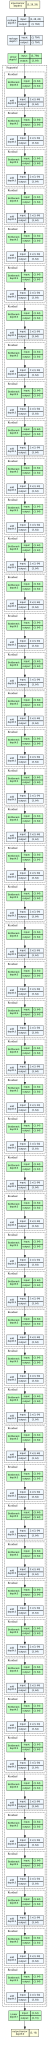

In [24]:
print("Network structure:")
print(bottleneck_network)

print("Forward kernel schema:")
model_graph = src.utils.model_visualization.draw_forward_kernel_graph(deep_feedforward_resnet_prenorm(), depth=3)
model_graph.visual_graph


# Loss and metrics

In this task we will use the same loss functions and metrics as in the previous notebooks:

- CrossEntropy as the loss function for training
- Accuracy as the metrics

In [25]:
import torchmetrics

def loss(batch):
    # return batch['signals']['output'].abs().sum()

    logits = batch['signals']['output']
    labels = batch['data']['label']

    return torch.nn.functional.cross_entropy(logits, labels)


losses = {'ce': loss}

def accuracy(batch):
    # return 0, 1

    preds = batch['postprocessed']['class']
    labels = batch['data']['label']
    
    correct = (preds == labels).sum().item()
    total = labels.numel()

    return correct, total

metrics = {'accuracy': accuracy}
optimizer = torch.optim.AdamW(
    params=bottleneck_network.parameters(),
    lr=1.0e-3,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
)

# ^^^ These variables should be set up in this task


In [26]:
answer['loss_names'] = list(losses.keys())
answer['metric_names'] = list(metrics.keys())

answer['test_loss_val'] = {f_name: function(check_batch) for f_name, function in losses.items()}
answer['test_metrics_val'] = {f_name: function(check_batch) for f_name, function in metrics.items()}

print("Losses:", losses)
print("Metrics:", metrics)


Losses: {'ce': <function loss at 0x7f0464c87a60>}
Metrics: {'accuracy': <function accuracy at 0x7f0464c86b60>}


# Dataloaders and other infrastructure

Use the same dataloaders as you have used in the Shallow Feedforward task

## Goal

Now it is time to start the training process.

First, turn the datasets into dataloaders. A dataloader creates mini-batches and can shuffle the data for us.

## Implementation Details

Use `torch.utils.data.DataLoader` to create training and validation dataloaders.

Important details:
- shuffle the training data;
- do not shuffle the validation data;
- use `drop_last=True` for the training dataloader so that all training batches have the same size;
- use the `batch_size` equal to 32


In [27]:
from tqdm import trange, tqdm
import os


batch_size = 32
train_dl = torch.utils.data.DataLoader(
    dataset=MNIST_train,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)
valid_dl = torch.utils.data.DataLoader(
    dataset=MNIST_valid,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,

)

# ^^^ These variables should be set up in this task

# Sanity checking that the dataloaders work
train_batch = next(iter(train_dl))
valid_batch = next(iter(valid_dl))

pprint(train_batch)
pprint(valid_batch)

# Storing the answers
answer['train_batch'] = str(train_batch)
answer['valid_batch'] = str(valid_batch)

{'image': tensor[32, 28, 28] n=25088 (98Kb) x∈[-1.000, 1.000] μ=-0.753 σ=0.597,
 'label': tensor[32] i64 x∈[0, 9] μ=4.719 σ=2.399}
{'image': tensor[32, 28, 28] n=25088 (98Kb) x∈[-1.000, 1.000] μ=-0.763 σ=0.587,
 'label': tensor[32] i64 x∈[0, 9] μ=4.125 σ=3.098}


# Visualizing gradient vanishing and paralysis

Create the following networks:

- a network with 1 default bottleneck block
- a network with 100 bottleneck blocks
- a network with 100 batchnorm bottleneck blocks
- a network with 100 residual bottleneck blocks
- a network with 100 batchnorm residual bottleneck blocks

For all these networks, plot the per-layer signals.

Fresh network: 1 default bottleneck block


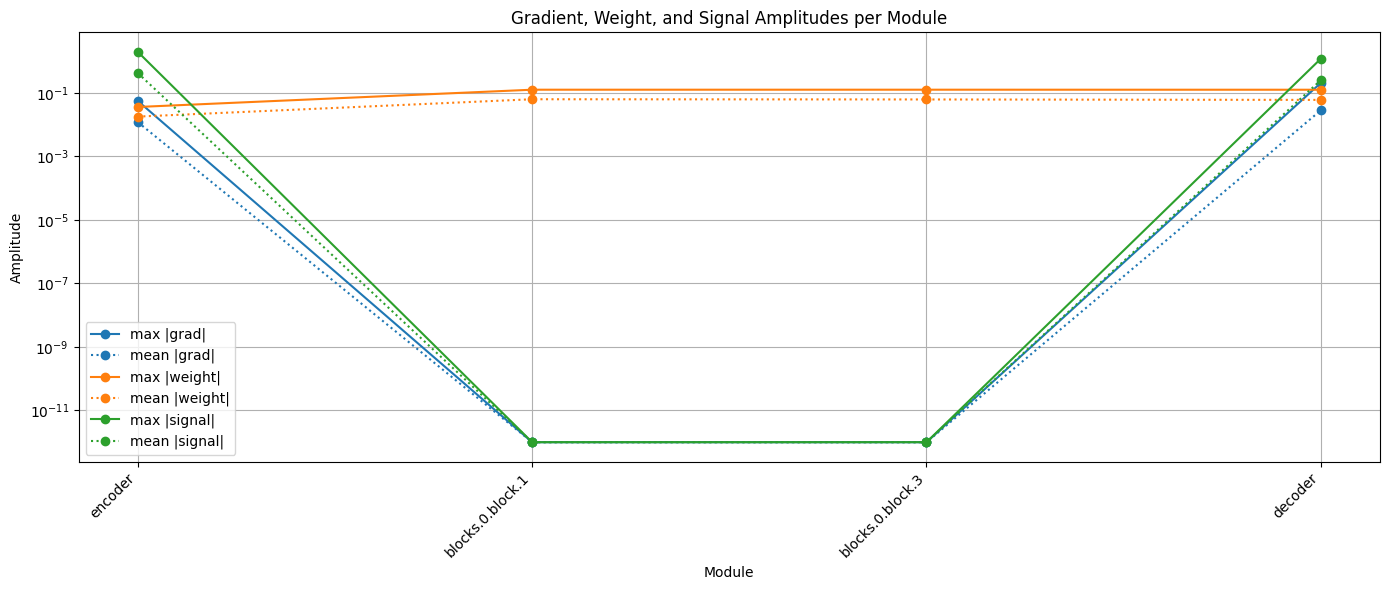

Fresh network: 100 default bottleneck blocks


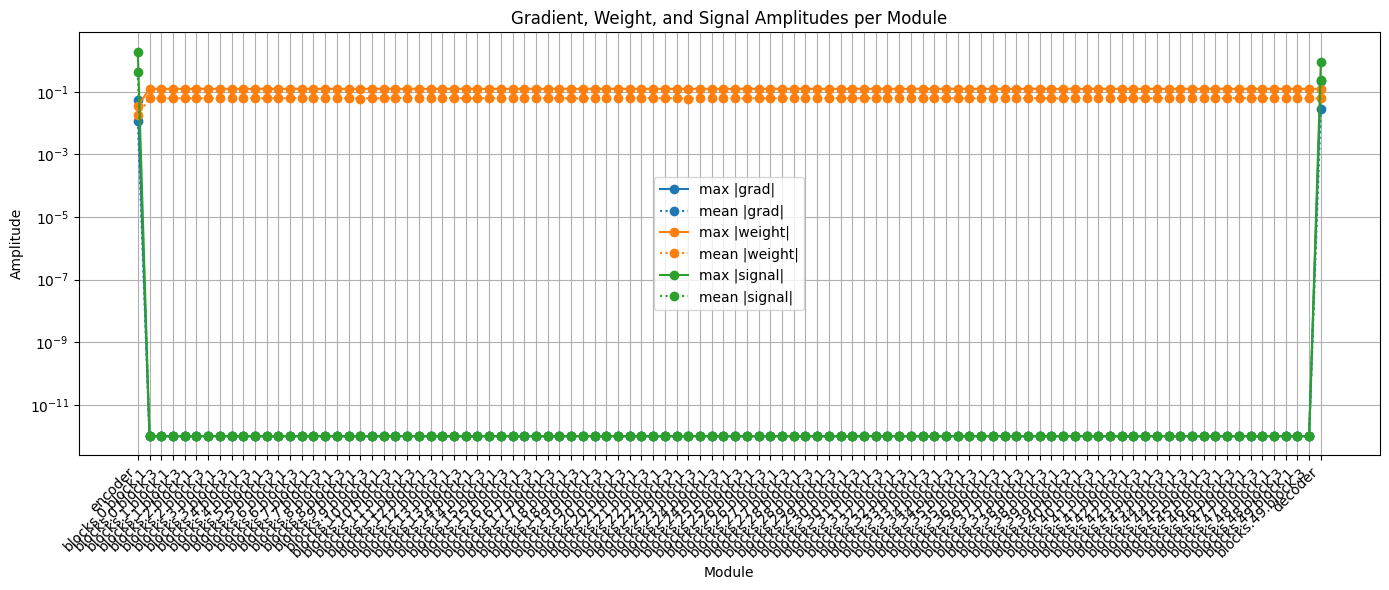

Fresh network: 100 default bottleneck blocks


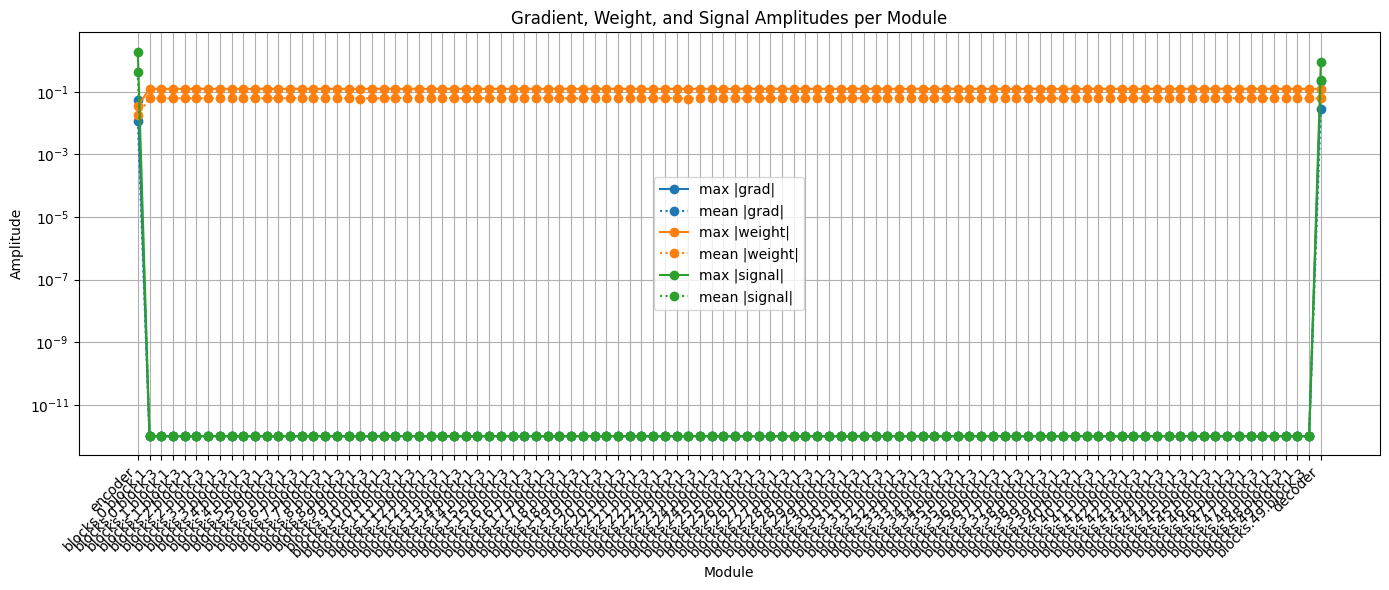

Fresh network: 100 default bottleneck blocks


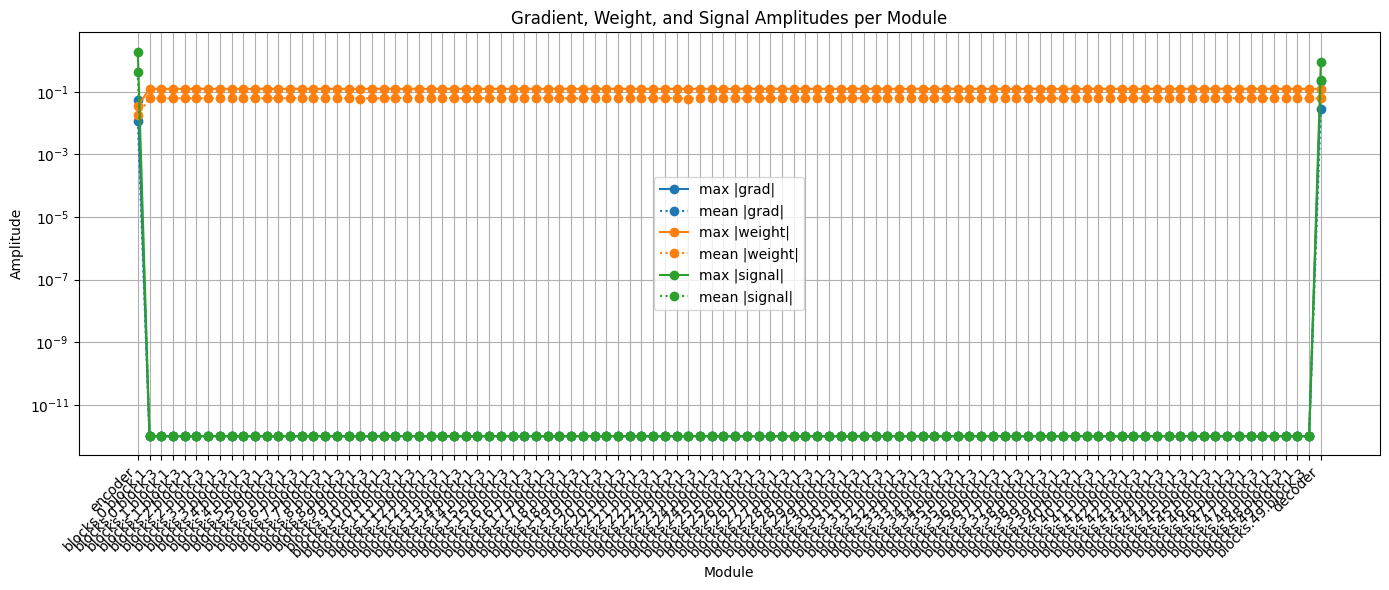

Fresh network: 100 default bottleneck blocks


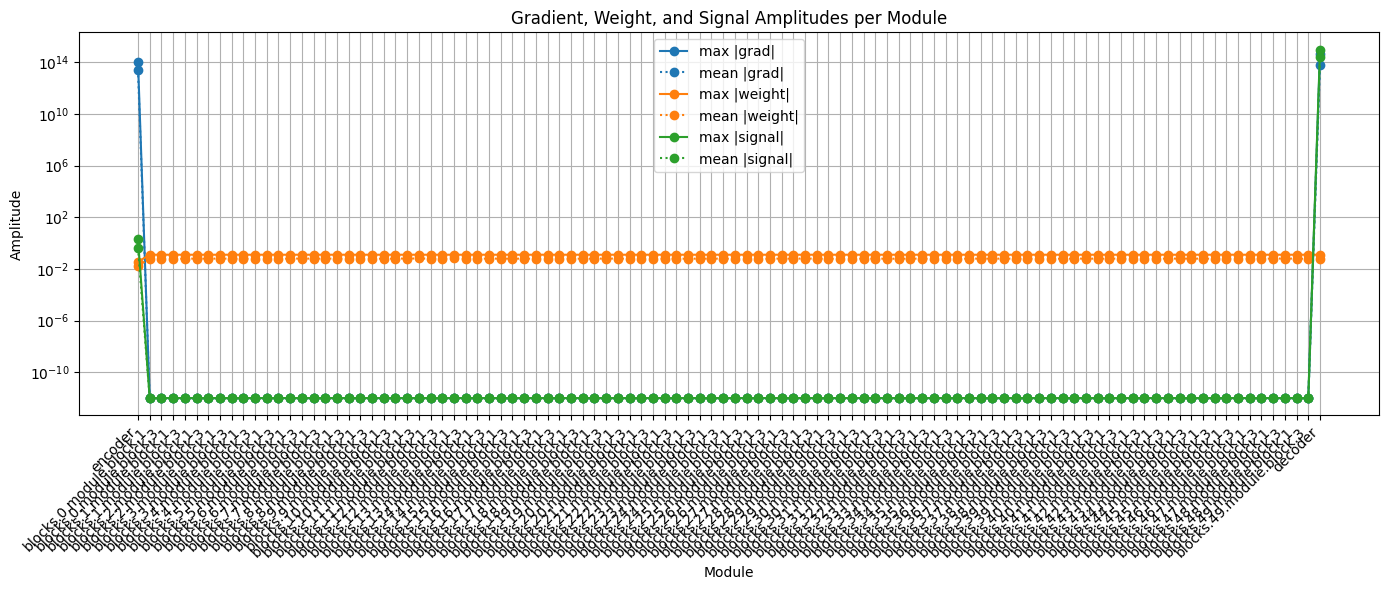

Fresh network: 100 default bottleneck blocks


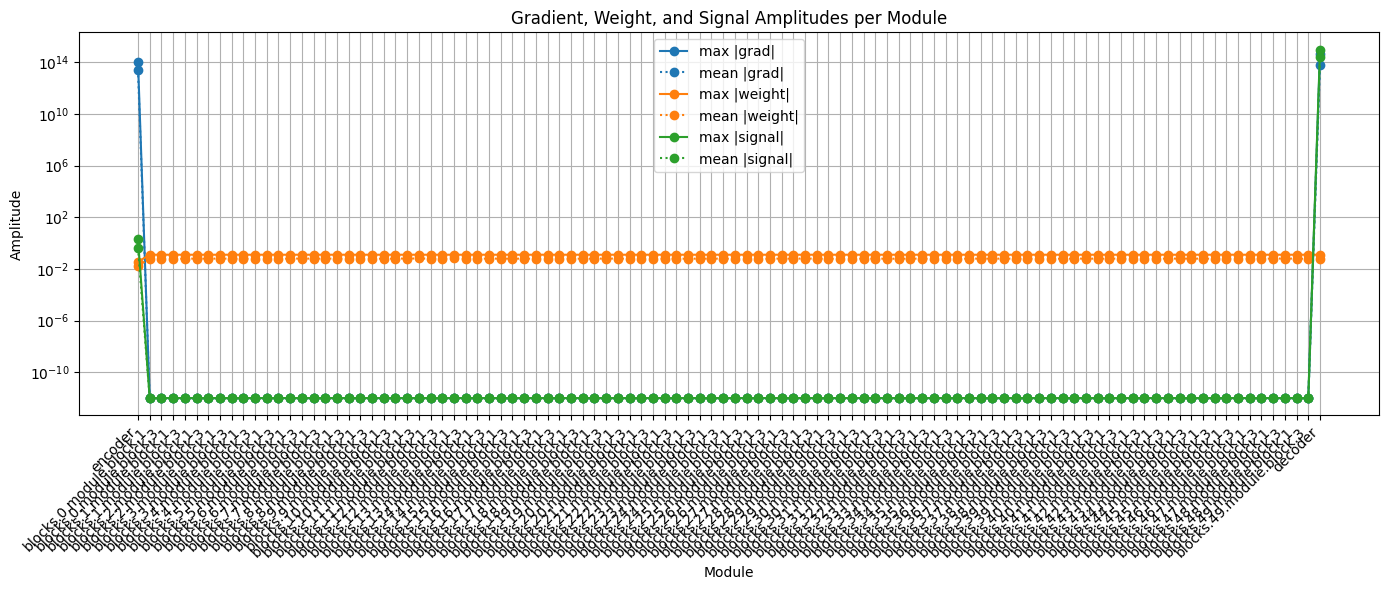

In [28]:
gradient_demo_batch = next(iter(valid_dl))
gradient_demo_dim_embed = 64
gradient_demo_deep_blocks = 50


def plot_fresh_signal_stats(title, model_factory, seed=0):
    src.utils.seed.seed_all(seed)
    model = model_factory()
    model.zero_grad(set_to_none=True)

    batch = {'data': gradient_demo_batch}
    model.train()
    model(batch)
    signal_stats_loss = losses['ce'](batch)
    signal_stats_loss.backward()

    print(title)
    src.utils.model_visualization.plot_signal_stats(model, {'data': gradient_demo_batch})
    return model


gradient_demo_models = {}

gradient_demo_models['1 default bottleneck block'] = plot_fresh_signal_stats(
    'Fresh network: 1 default bottleneck block',
    lambda: shallow_feedforward())

gradient_demo_models['100 default bottleneck blocks'] = plot_fresh_signal_stats(
    'Fresh network: 100 default bottleneck blocks',
    lambda: deep_feedforward())

gradient_demo_models['100 default bottleneck blocks'] = plot_fresh_signal_stats(
    'Fresh network: 100 default bottleneck blocks',
    lambda: deep_feedforward_prenorm())

gradient_demo_models['100 default bottleneck blocks'] = plot_fresh_signal_stats(
    'Fresh network: 100 default bottleneck blocks',
    lambda: deep_feedforward_postnorm())

gradient_demo_models['100 default bottleneck blocks'] = plot_fresh_signal_stats(
    'Fresh network: 100 default bottleneck blocks',
    lambda: deep_feedforward_resnet())

gradient_demo_models['100 default bottleneck blocks'] = plot_fresh_signal_stats(
    'Fresh network: 100 default bottleneck blocks',
    lambda: deep_feedforward_resnet_prenorm())

We can see a rather interesting behavior:
- a network without batchnorm has severe gradient vanishing
- a network with prenorm/postnorm batchnorm has gradient explosion 
> !!! which was a surprise for me personally !!!
> 
> This is because:
> - the weights matrix initialization assumes that input std is unit -- and inits the weights so that the output weights are also unit
> - afterwards ReLU activation changes std and makes it ~2x smaller
> - that means that in batchnorm we are dividing signals by 0.5 to preserve their gradients
> - when we are doing backprop, we also divide by 0.5, but this time this value is not directly connected to the actual gradient values
- a network with simple resnet has even distribution of gradients
- a network with resnet + batchnorm has a bit of gradient increase, but it is not critical

Thus we can do the following interesting conclusion:
- across the blocks, residual block makes gradient even across different levels of deep networks
- meanwhile, batchnorm solves another problem: it makes the gradient even across different signals within one layer

# Experiments

!!! DO NOT CHECK THIS PART !!!

(in case you do, this training will be included in checks and the ckecks will take a very long time)

It is time to do something interesting!

Train the networks created above for 20 epochs each and see the results. 
Figure out, which network trains the fastest and why. 

/usr/local/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/07/04 20:01:04 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$G

[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/665985386370026847/runs/5bcf83e3f6124e20975b501adba93d63)

Model moved to device: cpu


epochs:   0%|          | 0/20 [00:00<?, ?it/s]

batches:   0%|          | 0/1875 [00:00<?, ?it/s]

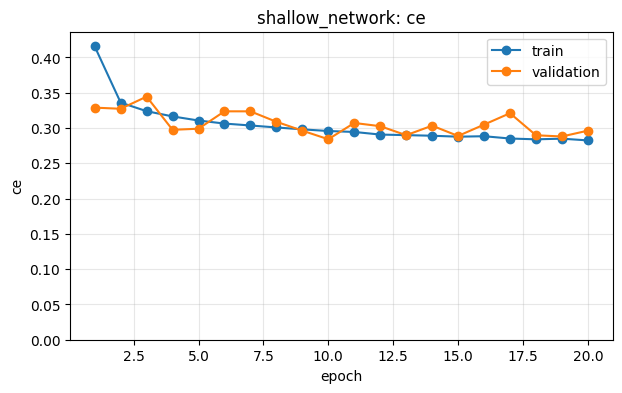

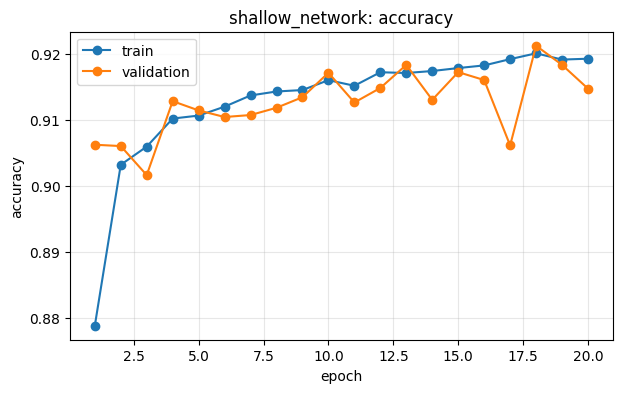

[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/665985386370026847/runs/372856f024f24a6eaeb0739775a04298)

2026/07/04 20:02:54 WARNING mlflow.utils.validation: Param value 'encoder: Linear(784, 64) | blocks.0.block.0: Identity | blocks.0.block.1: Linear(64, 64) | blocks.0....' (7900 characters) is truncated to 6000 characters to meet the length limit.


Model moved to device: cpu


epochs:   0%|          | 0/20 [00:00<?, ?it/s]

batches:   0%|          | 0/1875 [00:00<?, ?it/s]

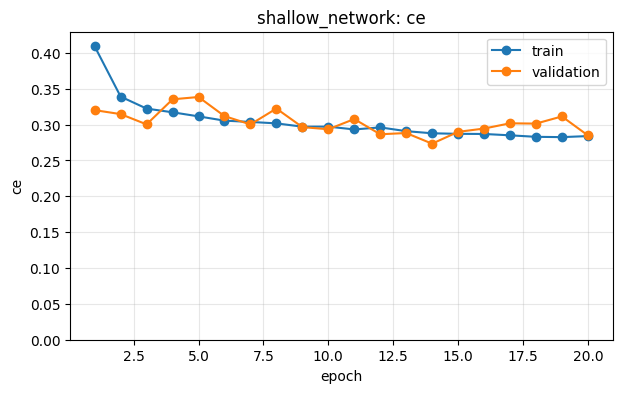

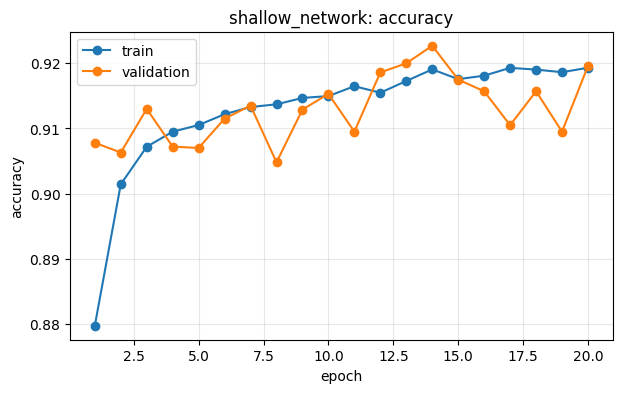

[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/665985386370026847/runs/d6c65c49d9924eb781b5ff0737e8b445)

2026/07/04 20:06:04 WARNING mlflow.utils.validation: Param value 'encoder: Linear(784, 64) | blocks.0.block.0: Identity | blocks.0.block.1: Linear(64, 64) | blocks.0....' (7950 characters) is truncated to 6000 characters to meet the length limit.


Model moved to device: cpu


epochs:   0%|          | 0/20 [00:00<?, ?it/s]

batches:   0%|          | 0/1875 [00:00<?, ?it/s]

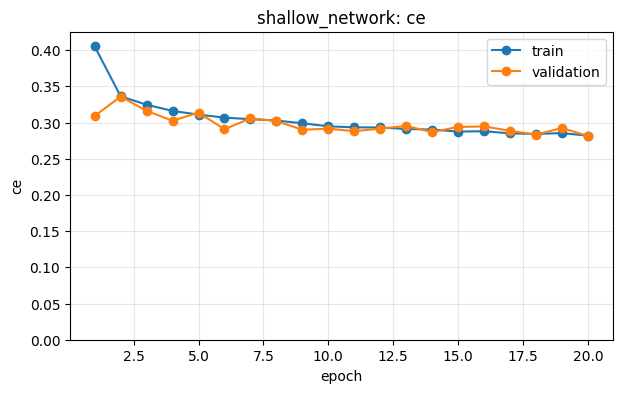

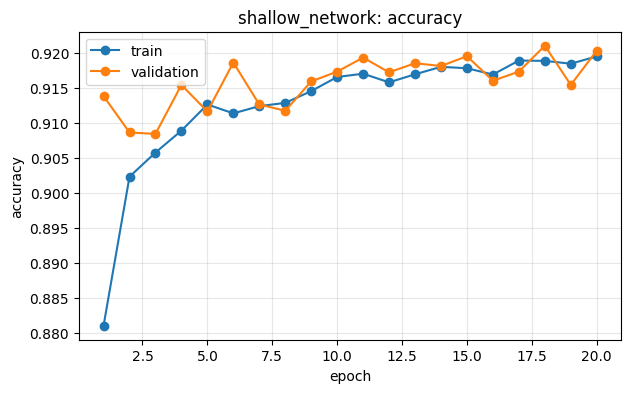

[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/665985386370026847/runs/4d60596ebe194a6e88b8cc5c672e12bb)

2026/07/04 20:09:16 WARNING mlflow.utils.validation: Param value 'encoder: Linear(784, 64) | blocks.0.block.0: BatchNorm | blocks.0.block.1: Linear(64, 64) | blocks.0...' (7950 characters) is truncated to 6000 characters to meet the length limit.


Model moved to device: cpu


epochs:   0%|          | 0/20 [00:00<?, ?it/s]

batches:   0%|          | 0/1875 [00:00<?, ?it/s]

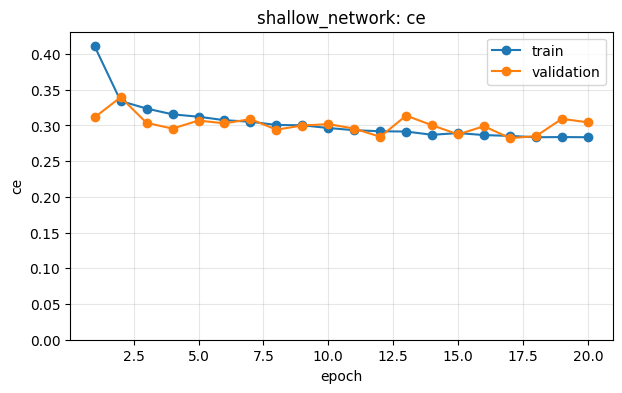

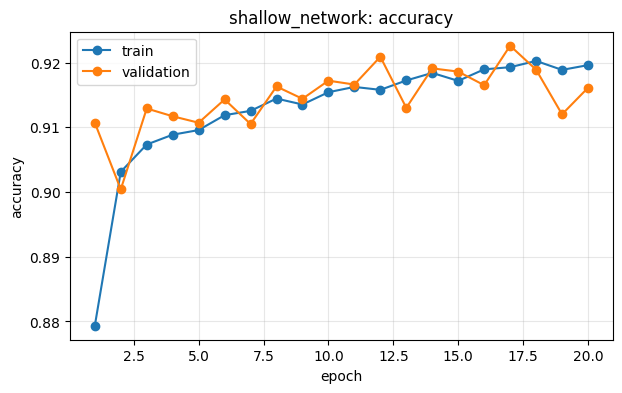

[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/665985386370026847/runs/01071670c54045f39bc83996a861e62b)

2026/07/04 20:12:39 WARNING mlflow.utils.validation: Param value 'encoder: Linear(784, 64) | blocks.0.module.block.0: Identity | blocks.0.module.block.1: Linear(64, 6...' (9650 characters) is truncated to 6000 characters to meet the length limit.


Model moved to device: cpu


epochs:   0%|          | 0/20 [00:00<?, ?it/s]

batches:   0%|          | 0/1875 [00:00<?, ?it/s]

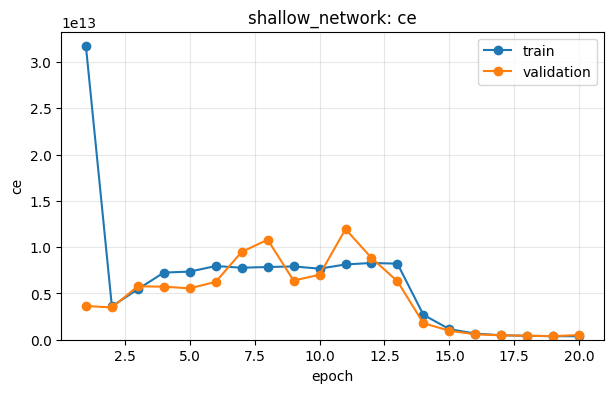

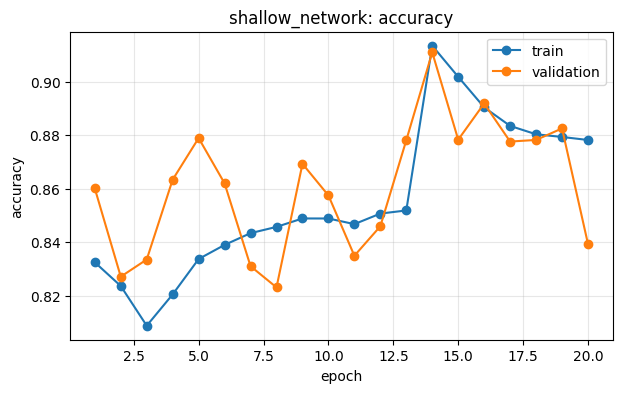

[Open MLflow run with graphs](http://127.0.0.1:5000/#/experiments/665985386370026847/runs/0cfb62eb54f04d059b7ed62b70342c2d)

2026/07/04 20:16:42 WARNING mlflow.utils.validation: Param value 'encoder: Linear(784, 64) | blocks.0.module.block.0: BatchNorm | blocks.0.module.block.1: Linear(64, ...' (9700 characters) is truncated to 6000 characters to meet the length limit.


Model moved to device: cpu


epochs:   0%|          | 0/20 [00:00<?, ?it/s]

batches:   0%|          | 0/1875 [00:00<?, ?it/s]

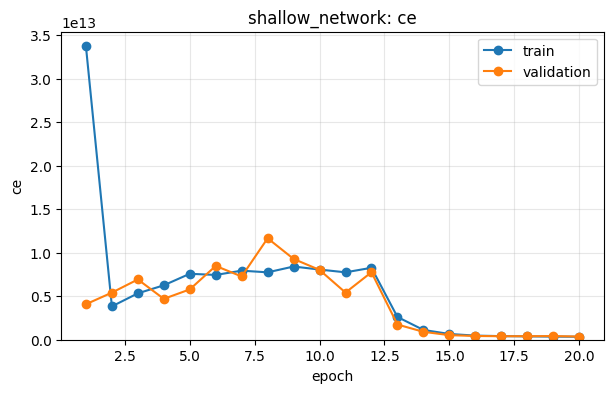

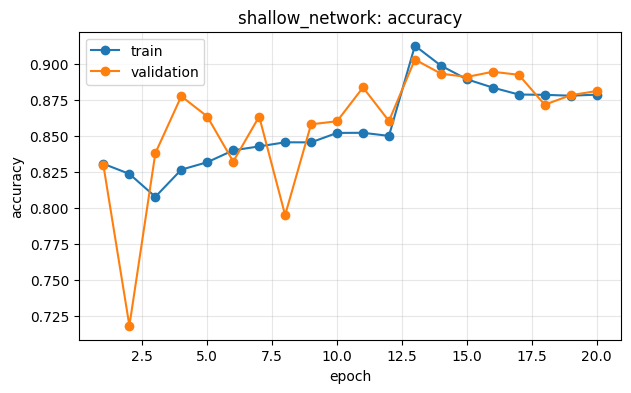

In [29]:
# for network_constructor in [shallow_feedforward, deep_feedforward, deep_feedforward_postnorm, deep_feedforward_prenorm, deep_feedforward_resnet, deep_feedforward_resnet_prenorm]:
#     network = network_constructor()

#     optimizer = torch.optim.AdamW(network.parameters(), lr=1.0e-3)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)

#     n_epochs = 20

#     training_logger = src.utils.mlflow.prepare_mlflow_logger(
#         str(network_constructor.__name__))

#     shallow_training_history = src.train_loop.train_model(
#         network,
#         n_epochs,
#         train_dl,
#         valid_dl,
#         losses,
#         optimizer,
#         metrics=metrics,
#         scheduler=scheduler,
#         mlflow_logger=training_logger,
#         run_name='shallow_network')

#     train_loss_history = shallow_training_history['train_loss']['ce']
#     valid_loss_history = shallow_training_history['valid_loss']['ce']
#     train_acc_history = shallow_training_history['train_metrics']['accuracy']
#     valid_acc_history = shallow_training_history['valid_metrics']['accuracy']

#     training_logger.end()


In [ ]:
json_tricks.dump(utils.torch_to_numpy(answer), '.answer.json')
